# Plot Fisheye Keypoints
Visualize các điểm correspondence `(x_pitch, y_pitch)` → `[pixel_x, pixel_y]` lên ảnh fisheye.

In [ ]:
# ── Cài thư viện nếu chưa có ──────────────────────────────────────
# !pip install opencv-python matplotlib numpy

In [1]:
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

print('Libraries loaded OK')

Libraries loaded OK


In [2]:
# ── Config: đổi 2 path này cho đúng với máy bạn ───────────────────
IMAGE_PATH      = r"D:\UITs subject\Năm 3\Nhận dạng\CS318_RECOGNITION_SOCCERTRACK_MOT\detection\images\test\F_20220220_1_1800_1830_1.jpg"         # ảnh fisheye
KEYPOINTS_PATH  = r"D:\UITs subject\Năm 3\Nhận dạng\CS318_RECOGNITION_SOCCERTRACK_MOT\Data\fisheye_keypoints.json"  # file JSON keypoints

# Nếu bạn muốn paste trực tiếp keypoints (không cần file JSON),
# comment 2 dòng trên và uncomment block KEYPOINTS bên dưới.

In [5]:
with open(KEYPOINTS_PATH, "r", encoding="utf-8") as f:
    keypoints = json.load(f)

pts = [(eval(k)[0], eval(k)[1], v[0], v[1]) for k, v in keypoints.items()]
print(f'Loaded {len(pts)} keypoints')

Loaded 65 keypoints


In [6]:
# ── Load ảnh ──────────────────────────────────────────────────────
img = cv2.imread(IMAGE_PATH)
assert img is not None, f'Không đọc được ảnh: {IMAGE_PATH}'
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
print(f'Image: {w} x {h} px')

Image: 6500 x 1000 px


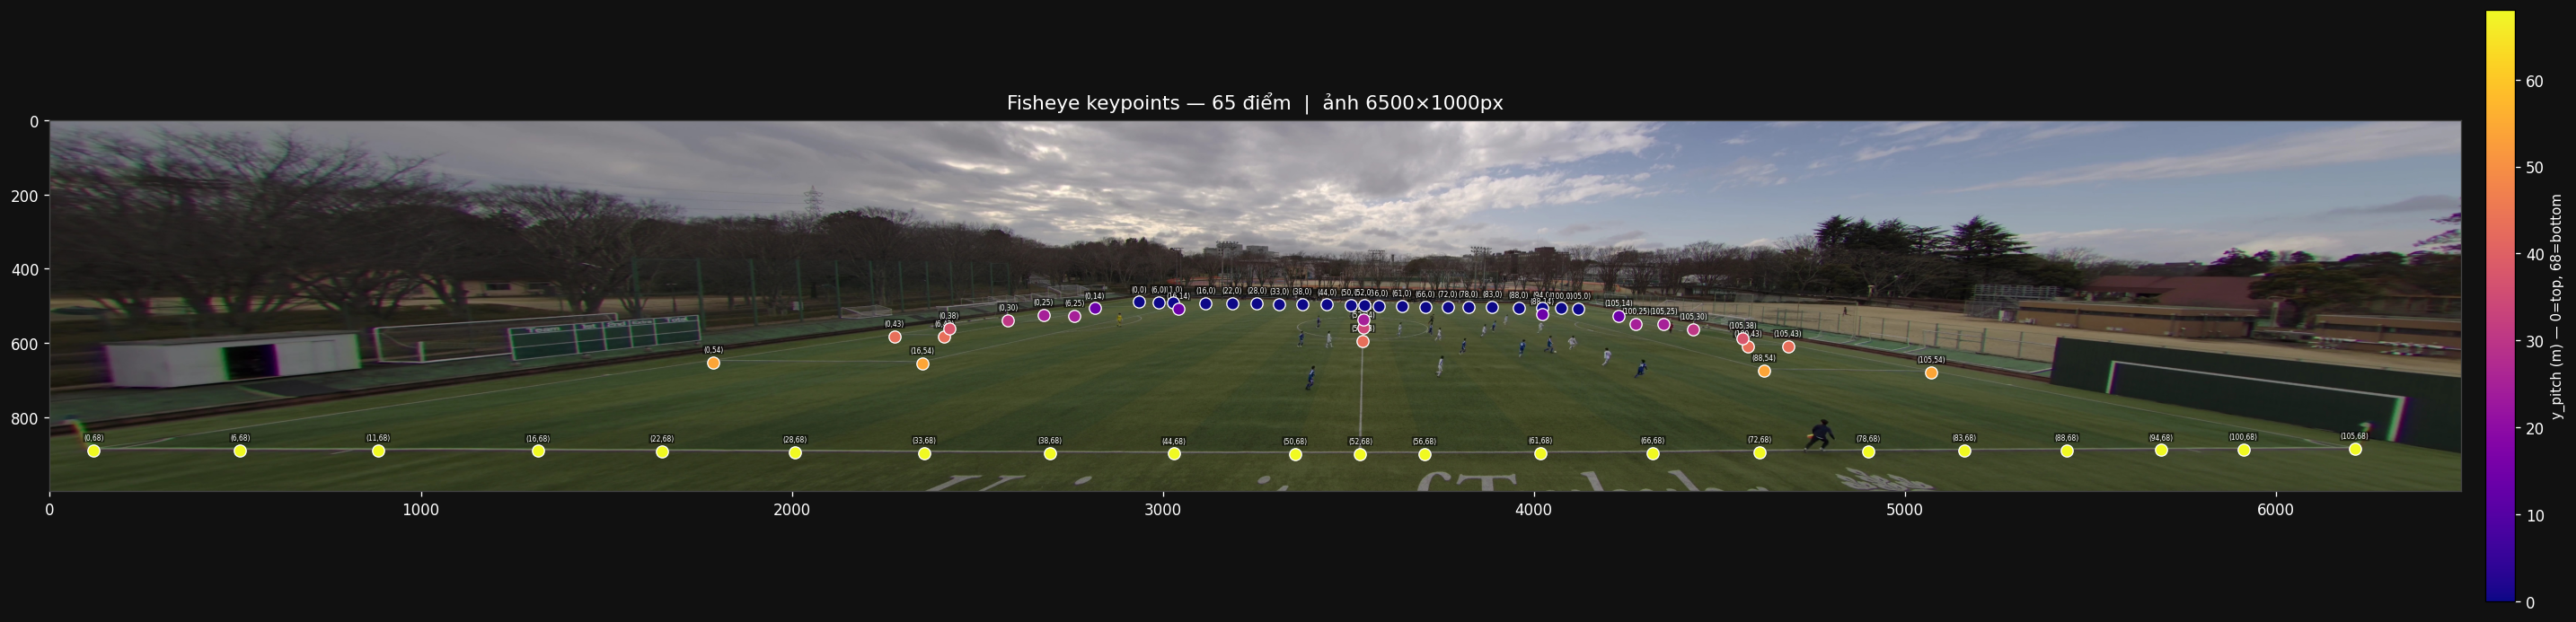

Saved → keypoints_on_fisheye.jpg


In [7]:
# ── Plot keypoints lên ảnh ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(24, 7), dpi=120)
ax.imshow(img_rgb)

cmap = plt.cm.plasma

for x_p, y_p, px, py in pts:
    color = cmap(y_p / 68.0)
    ax.plot(px, py, 'o',
            color=color, markersize=8,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5)
    ax.annotate(f'({x_p:.0f},{y_p:.0f})',
                (px, py),
                textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=4.5, color='white',
                bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.55, lw=0))

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=68))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, fraction=0.012)
cbar.set_label('y_pitch (m) — 0=top, 68=bottom', fontsize=9, color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_title(f'Fisheye keypoints — {len(pts)} điểm  |  ảnh {w}×{h}px',
             color='white', fontsize=13, pad=8)
ax.set_facecolor('#111')
fig.patch.set_facecolor('#111')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('keypoints_on_fisheye.jpg', dpi=150, bbox_inches='tight', facecolor='#111')
plt.show()
print('Saved → keypoints_on_fisheye.jpg')

In [8]:
# ── BONUS: tính homography H từ keypoints ─────────────────────────
src_pts = np.float32([[px, py]   for _, _, px, py in pts])   # pixel
dst_pts = np.float32([[xp, yp]   for xp, yp, _, _ in pts])  # pitch (m)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransacReprojThreshold=2.0)
H_inv   = np.linalg.inv(H)

inliers = mask.ravel().sum()
print(f'Homography H computed — inliers: {inliers}/{len(pts)}')
print('H =\n', np.round(H, 6))

# Quick test: project 1 điểm pixel → pitch
test_px = np.array([src_pts[0][0], src_pts[0][1], 1.0])
proj    = H @ test_px
proj   /= proj[2]
print(f'\nTest: pixel {src_pts[0]} → pitch {proj[:2].round(2)}  (expected {dst_pts[0]})')

Homography H computed — inliers: 62/65
H =
 [[-2.24040000e-02 -1.58200000e-01  1.43015528e+02]
 [ 3.91300000e-03 -2.54468000e-01  1.12918996e+02]
 [ 5.80000000e-05 -2.99900000e-03  1.00000000e+00]]

Test: pixel [3029.57  898.73] → pitch [44.1  68.37]  (expected [44. 68.])
